In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd

import igl 
from scipy.sparse.linalg import eigsh
from tqdm import tqdm

In [2]:
from src import utils 

import importlib
import src.fatemarkers
import src.meshharm

importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)
from src.fatemarkers import FateMarkers

In [3]:
path = 'Data/20251001/'

timepoints = ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

zarr_names = {
        'day1p5': 'r0.zarr',
        'day2':'r0.zarr',
        'day2p5':'r0.zarr',
        'day3':'r0.zarr',
        'day3p5':'r0.zarr',
        'day4':'r0.zarr',
        'day4p5':'r0.zarr',
        'day4p5-more':'r0.zarr',
}


wells = {
    'day1p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day2p5': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06'],
    'day3': ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'B02', 'B03'],
    'day3p5': ['A01', 'A02', 'A03', 'A04', 'B03'],
    'day4': ['A02', 'A03', 'A04', 'A05', 'A06', 'B01', 'B02'],
    'day4p5': ['A06', 'B06'],
    'day4p5-more': ['C01', 'C02', 'C03', 'C04', 'C05', 'C06'],
}

rounds = {
'day1p5': ['0_fused_zillum_registered'],
'day2': ['0_fused_zillum_registered'],
'day2p5': ['0_fused_zillum_registered'],
'day3': ['0_fused_zillum_registered'],
'day3p5': ['0_fused_zillum_registered'],
'day4': ['0_fused_zillum_registered'],
'day4p5': ['0_fused_zillum_registered'],
'day4p5-more': ['0_fused_zillum_registered'],
}

meshes = {
    'day1p5': ['nnorg_linked_multi_annotated'],
    'day2': ['nnorg_linked_multi_annotated'],
    'day2p5': ['nnorg_linked_multi_annotated'],
    'day3': ['nnorg_linked_multi_annotated'],
    'day3p5': ['nnorg_linked_multi_annotated'],
    'day4': ['nnorg_linked_multi_annotated'],
    'day4p5': ['nnorg_linked_multi_annotated'],
    'day4p5-more': ['nnorg_linked_multi_annotated'],
}

tables = {
    'day1p5':['cell_features'],
    'day2':['cell_features'],
    'day2p5':['cell_features'],
    'day3':['cell_features'],
    'day3p5':['cell_features'],
    'day4':['cell_features'],
    'day4p5':['cell_features'],
    'day4p5-more':['cell_features'],
}

times_dic = {
    '1p5': 1.5,
    '2': 2,
    '2p5': 2.5,
    '3': 3,
    '3p5': 3.5,
    '4': 4,
    '4p5': 4.5,
    '4p5-more': 4.6,
}



In [8]:
# load the hks vocabs 
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab_hks = res['vocab']
sigma_hks = res['sigma']
scaler_hks = res['scaler'].item() 
ts = res['ts']

In [ ]:
def complexity(m): 
    errs = [] 
    ls = np.arange(1, 7)
    for l in ls:
        err = m.compute_recon_quality(lmax=l) 
        errs.append(err)
    return np.array(errs) 

def load_bof(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    hks = m.compute_hks_for_new_times(ts, coeffs=False)
    hks_scaled = scaler_hks.transform(hks / np.mean(hks, axis=0) - 1)
    dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab_hks[np.newaxis, :, :], axis=2)
    encoding = np.exp(-dist**2 / (2 * sigma_hks**2))
    coeffs_hks = m.modes.T @ (m.mass_matrix @ encoding)
    spectrums = m.compute_spectrum(coeffs_hks)
    
    area = m.area
    c = complexity(m)

    return np.sqrt(spectrums/m.mass_matrix.diagonal().sum()), frac_diff, area, c 


def load(save_path): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()

    hks = m.compute_hks_for_new_times([1, 4, 25, 100], coeffs=False)
    coeffs_hks = m.modes.T @ (m.mass_matrix @ hks)
    spectrums = m.compute_spectrum(coeffs_hks)
    area = m.area
    c = complexity(m)
    return np.sqrt(spectrums/m.area), frac_diff, area, c


In [13]:
spectrums = [] 
times = [] 
fracs = [] 
ids = [] 
areas = [] 
complexities = []

for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint][0]

        file_path = f"{path}{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy").astype('int')
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                try: 
                    bof_spectrum, frac, a, c = load_bof(save_path, ts)
                    spectrums.append(bof_spectrum)
                    times.append(timepoint[3:])
                    fracs.append(frac)
                    areas.append(a)
                    complexities.append(c)
                    ids.append(f"{timepoint}_{well_name}_{label}") 
                except: 
                    print(f"Failed to load {save_path}")
                    continue

 42%|████▎     | 51/120 [00:04<00:05, 11.57it/s]

Failed to load Data/20251001/day4p5-more/r0.zarr/C/03/0_fused_zillum_registered//fm_data/20


100%|██████████| 60/60 [00:05<00:00, 10.58it/s]


(2808, 6)


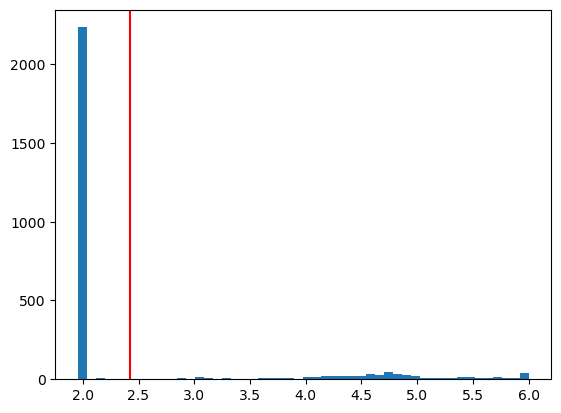

In [291]:
threshold = 0.015

l_cross_values = [] 
for errs in complexities: 
    # interpolate to find the l value where err crosses the threshold
    if errs[-1] > threshold:
        l_cross_values.append(6)
    else: 
        l_cross = np.interp(threshold, errs[::-1], np.arange(6, 0, -1))
        l_cross_values.append(l_cross)
l_cross_values = np.array(l_cross_values)

threshold = np.percentile(l_cross_values, 80)
print(complexities.shape)
plt.hist(l_cross_values, bins=50)
plt.axvline(threshold, color='red')
plt.show() 

In [292]:
threshold = np.percentile(fracs, 95)
print(len(fracs))
recon_mask = (np.array(fracs) < threshold) & (l_cross_values > 2.5) 
print(recon_mask.sum())

# Convert boolean mask to indices array
recon_indices = np.where(recon_mask)[0]

filtered_times = np.array(times)[recon_mask]
filtered_spectrums = np.array(spectrums)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]
filtered_areas = np.array(areas)[recon_mask]
filtered_complexities = np.array(complexities)[recon_mask]

2808
419


In [51]:
np.savez('sim/multi_shape_bof_results_raw_value.npz', 
         filtered_ids=filtered_ids,
         filtered_time=filtered_times,
         filtered_spectrums=filtered_spectrums,
         filtered_areas=filtered_areas,
         filtered_complexities=filtered_complexities
)

In [52]:
res = np.load('sim/multi_shape_bof_results_raw_value.npz', allow_pickle=True)
filtered_ids = res['filtered_ids']
filtered_times = res['filtered_time']
filtered_spectrums = res['filtered_spectrums']
filtered_areas = res['filtered_areas']
filtered_complexities = res['filtered_complexities']

(419, 8, 8)
0.018134767


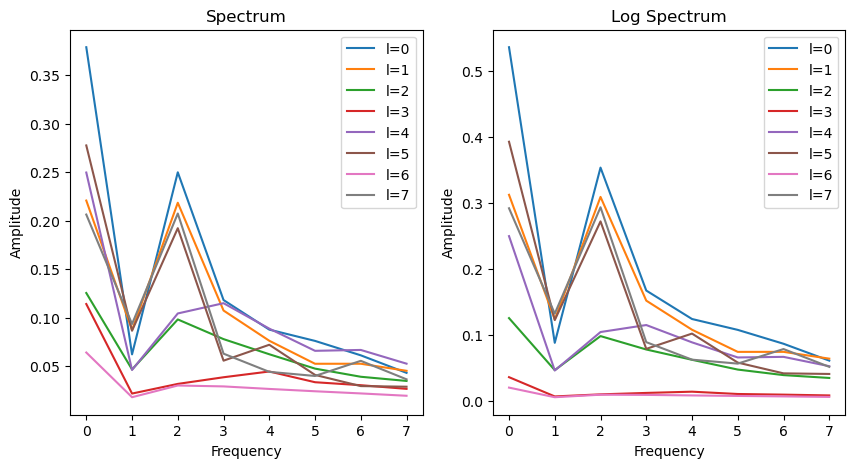

(419, 8, 8)


In [293]:
bof_spectrums = np.array(filtered_spectrums[:, :, :])
bof_scaled = np.empty_like(bof_spectrums)
print(bof_spectrums.shape)

minimum = np.min(np.mean(bof_spectrums, axis=0))
print(minimum)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

weights = np.sqrt(np.array([2, 2, 1, 0.1, 1, 2, 0.1, 2])) 
ksq = np.arange(1, bof_spectrums.shape[1]+1)

ks = np.arange(1, bof_spectrums.shape[1]+1)
for i in range(bof_spectrums.shape[-1]):
    axes[0].plot(np.mean(bof_spectrums[:, :, i], axis=0), label=f'l={i}')
    bof_scaled[:, :, i] =  bof_spectrums[:, :, i]*weights[i] 

    axes[1].plot(np.mean(bof_scaled[:, :, i], axis=0), label=f'l={i}')

axes[0].legend()
axes[0].set_title("Spectrum")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Amplitude")

axes[1].legend()
axes[1].set_title("Log Spectrum")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Amplitude")

plt.show()

bof_scaled = bof_scaled[:, :8, :]
print(bof_scaled.shape) 

In [294]:
# Reshape the bag-of-features spectrums for feature selection
bof_spectrums_reshaped = bof_scaled.reshape(bof_spectrums.shape[0], -1)

# bof_spectrums_scaled = StandardScaler().fit_transform(bof_spectrums_reshaped)
bof_spectrums_scaled = np.copy(bof_spectrums_reshaped) 

In [295]:
from sklearn.cluster import MeanShift

n_clusters = 10
kmeans_spectrums = KMeans(n_clusters=n_clusters, random_state=42)
kmeans_spectrums.fit(bof_spectrums_scaled)

# dist = kmeans_spectrums.transform(bof_spectrums_scaled)
cluster_id = kmeans_spectrums.labels_


from sklearn.manifold import MDS, TSNE, Isomap, LocallyLinearEmbedding
mds = TSNE(n_components=2, perplexity=30, random_state=42)

# mds = Isomap(n_components=2, n_neighbors=15)
# mds = MDS(n_components=2, random_state=42, n_init=4)

# mds = PCA(n_components=2)

to_fit = np.concatenate((bof_spectrums_scaled, kmeans_spectrums.cluster_centers_), axis=0)
mds.fit(to_fit)
reduced_dim_rep = mds.fit_transform(to_fit)

spectrum_pcs = reduced_dim_rep[:bof_spectrums_scaled.shape[0], :]
cluster_pcs = reduced_dim_rep[bof_spectrums_scaled.shape[0]:, :]


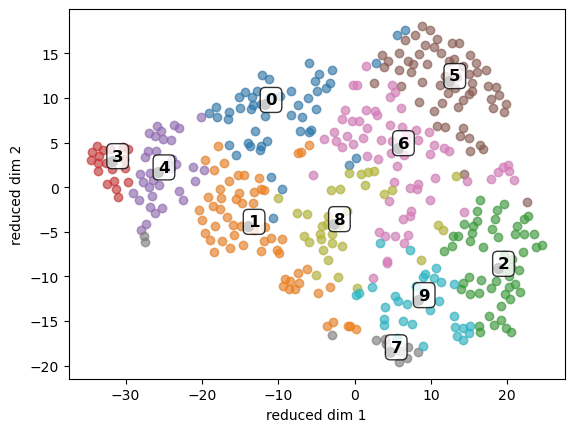

In [296]:
plt.plot(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 'o', alpha=0.3, c='grey')

for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(spectrum_pcs[mask, 0], spectrum_pcs[mask, 1], 'o', alpha=0.5)

plt.plot(cluster_pcs[:, 0], cluster_pcs[:, 1], 'o', markersize=7, color='black')
for i in range(len(cluster_pcs)): 
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.show()

['1p5' '2' '2p5' '3' '3p5' '4' '4p5' '4p5-more']


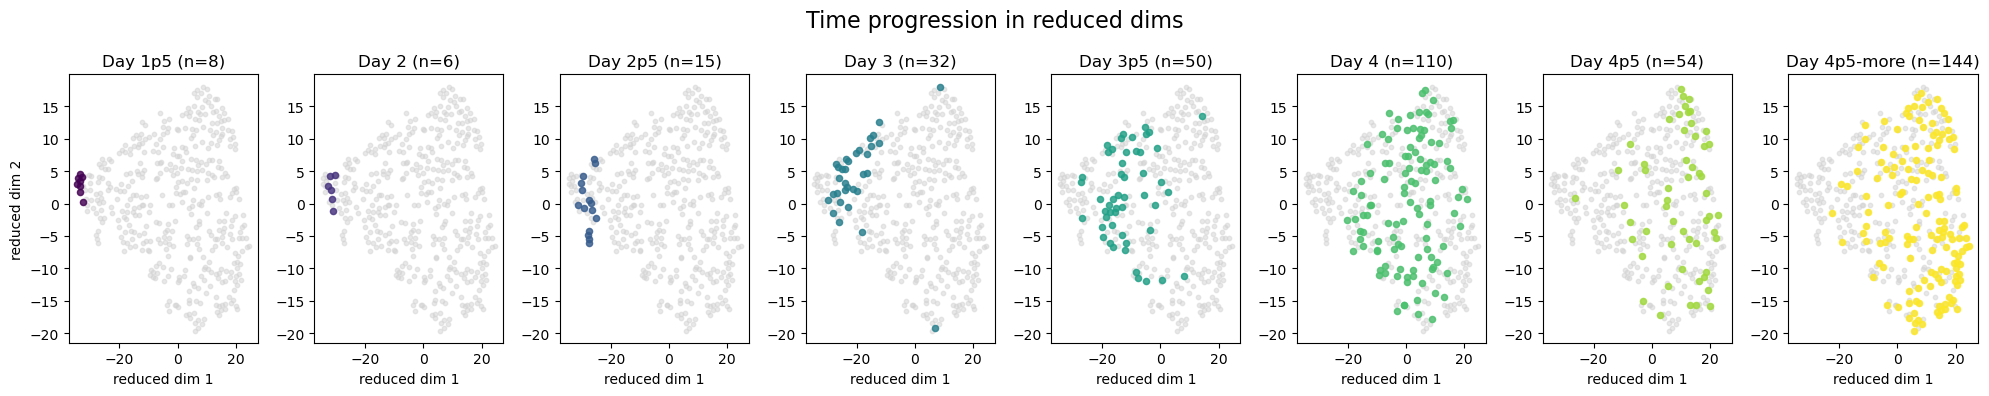

In [297]:
# Create subplots for each timepoint - spectrum PCA
unique_times = np.unique(filtered_times)

print(unique_times)
# Use a continuous colormap that represents time progression
cmap = plt.cm.viridis  # You can also try 'plasma', 'inferno', 'magma', 'cool', 'warm'
colors = [cmap(i / (len(unique_times) - 1)) for i in range(len(unique_times))]

fig, axes = plt.subplots(1, 8, figsize=(20, 4))

for i, time in enumerate(unique_times):
    ax = axes[i]
    
    # Plot all points in light gray
    ax.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], 
              c='lightgray', alpha=0.5, s=10)
    
    # Highlight current timepoint with color from continuous map
    times_mask = (filtered_times == time)
    ax.scatter(spectrum_pcs[:, 0][times_mask], spectrum_pcs[:, 1][times_mask], 
              c=[colors[i]], alpha=0.8, s=20, label=f'Day {time}')
    
    ax.set_xlabel('reduced dim 1')
    ax.set_title(f'Day {time} (n={np.sum(times_mask)})')

axes[0].set_ylabel('reduced dim 2')
plt.suptitle('Time progression in reduced dims', fontsize=16)
plt.tight_layout()
plt.show()

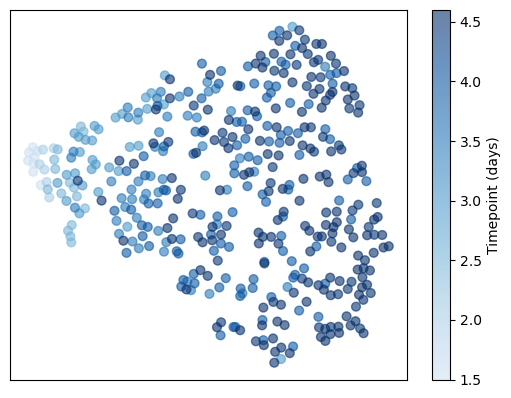

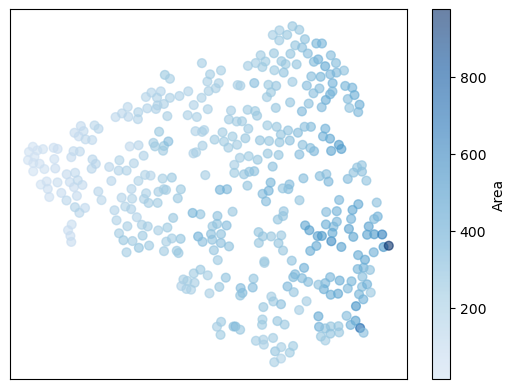

In [298]:
cmap = plt.get_cmap('Blues')

# Use only the darker portion of Blues colormap (50% to 100%)
colors = cmap(np.linspace(0.2, 1.0, 256))
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(colors)

times_array = [times_dic[t] for t in filtered_times]

plt.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=times_array, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(label='Timepoint (days)')
# plt.xlabel('PC1 \n Explained var: %.1f%%' % (mds.explained_variance_ratio_[0]*100))
plt.xticks([])
plt.yticks([])
# plt.ylabel('PC2 \n Explained var: %.1f%%' % (mds.explained_variance_ratio_[1]*100))
plt.show() 

plt.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=filtered_areas, s=40, alpha=0.6, cmap=custom_cmap)
plt.colorbar(label='Area')
# plt.xlabel('PC1 \n Explained var: %.1f%%' % (mds.explained_variance_ratio_[0]*100))
plt.xticks([])
plt.yticks([])
# plt.ylabel('PC2 \n Explained var: %.1f%%' % (mds.explained_variance_ratio_[1]*100))
plt.show() 

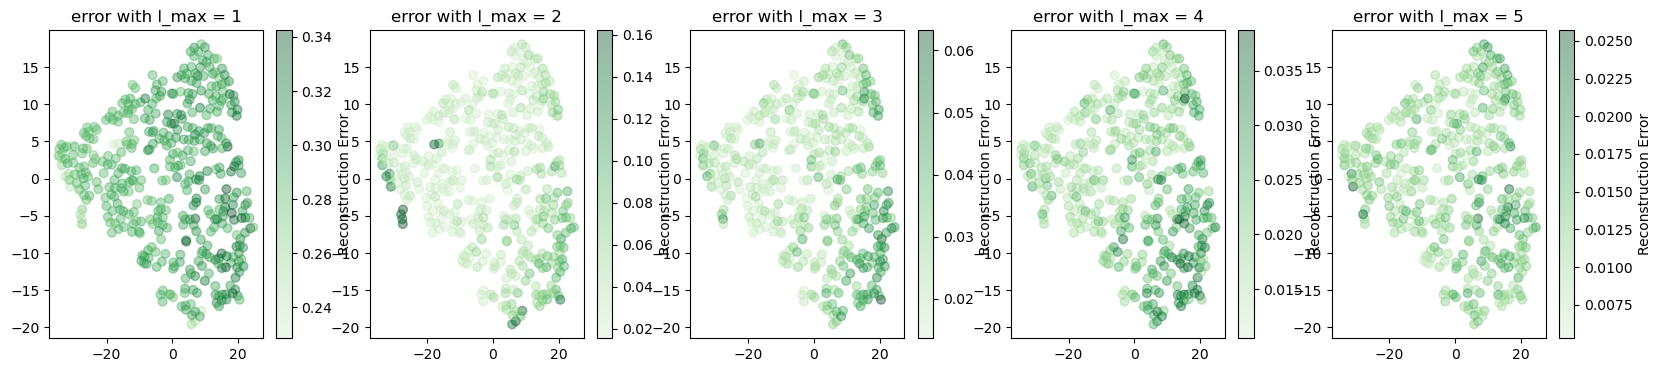

In [299]:
cmap = plt.get_cmap('Greens')


# Use only the darker portion of Blues colormap (50% to 100%)
colors = cmap(np.linspace(0.2, 1.0, 256))
from matplotlib.colors import ListedColormap
custom_cmap = ListedColormap(colors)

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    im = axes[i].scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=filtered_complexities[:, i], s=40, alpha=0.4, cmap=custom_cmap)
    axes[i].set_title('error with l_max = {}'.format(i+1))
    
    # add colorbar
    cbar = plt.colorbar(im, ax=axes[i], alpha=1)
    cbar.set_label('Reconstruction Error')
    
plt.show()

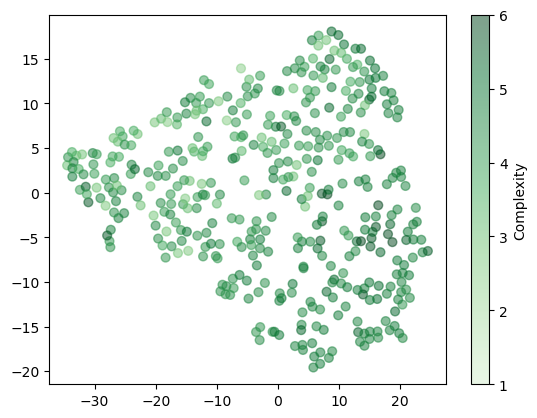

In [301]:
threshold = 0.015

l_cross_values = [] 
for errs in filtered_complexities: 
    # interpolate to find the l value where err crosses the threshold
    if errs[-1] > threshold:
        l_cross_values.append(6)
    else: 
        l_cross = np.interp(threshold, errs[::-1], np.arange(6, 0, -1))
        l_cross_values.append(l_cross)
l_cross_values = np.array(l_cross_values)

im = plt.scatter(spectrum_pcs[:, 0], spectrum_pcs[:, 1], c=l_cross_values, s=40, alpha=0.5, vmin=1, vmax=6, cmap=custom_cmap)
plt.colorbar(im, label='Complexity')
plt.show() 



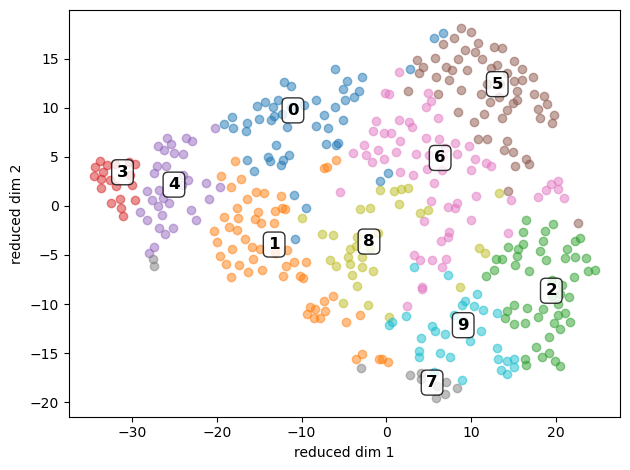

Cluster 0, closest IDs: ['day3_A05_86', 'day3p5_A04_64'] 
Cluster 1, closest IDs: ['day3p5_A03_30', 'day4_A06_62'] 
Cluster 2, closest IDs: ['day4p5-more_C03_55', 'day4p5-more_C02_34'] 
Cluster 3, closest IDs: ['day2_A06_25', 'day2_A03_23'] 
Cluster 4, closest IDs: ['day3_B02_88', 'day3_B03_10'] 
Cluster 5, closest IDs: ['day4p5-more_C02_112', 'day4p5_B06_62'] 
Cluster 6, closest IDs: ['day4p5-more_C03_35', 'day4_A03_12'] 
Cluster 7, closest IDs: ['day4p5-more_C03_99', 'day4_B01_38'] 
Cluster 8, closest IDs: ['day4p5_B06_34', 'day3p5_A03_69'] 
Cluster 9, closest IDs: ['day4p5-more_C04_88', 'day4p5-more_C05_122'] 


In [307]:
from scipy.spatial.distance import pdist, squareform

for id in range(n_clusters): 
    mask = (cluster_id == id)
    plt.plot(spectrum_pcs[mask, 0], spectrum_pcs[mask, 1], 'o', alpha=0.5)

for i in range(len(cluster_pcs)): 
    plt.text(cluster_pcs[i, 0], cluster_pcs[i, 1], 
             str(i), fontsize=12, fontweight='bold', 
             bbox=dict(boxstyle="round,pad=0.3", facecolor='white', edgecolor='black', alpha=0.8))

plt.xlabel('reduced dim 1')
plt.ylabel('reduced dim 2')
plt.tight_layout()
plt.show()

for (i, c) in enumerate(kmeans_spectrums.cluster_centers_):
    dist = np.linalg.norm(c - bof_spectrums_scaled, axis=1)
    closest_indices = np.argsort(dist)[:4]
    print(f"Cluster {i}, closest IDs: ['{filtered_ids[closest_indices[0]]}', '{filtered_ids[closest_indices[1]]}'] ")


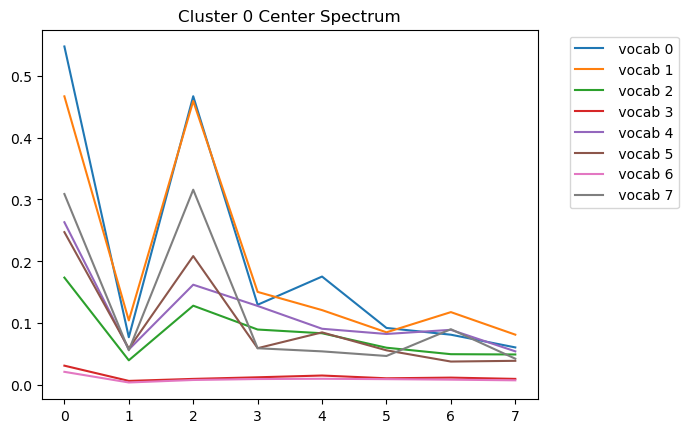

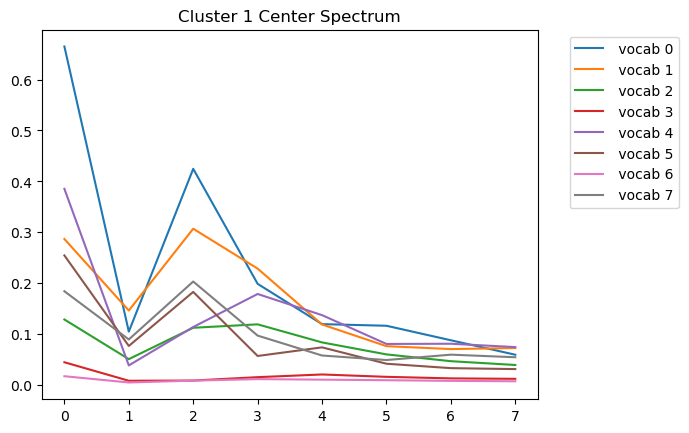

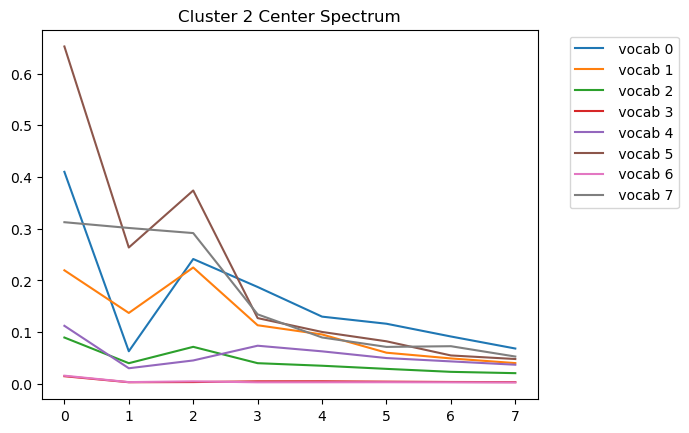

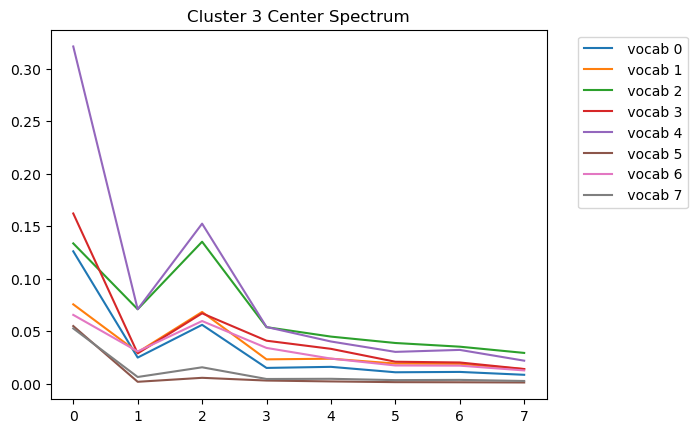

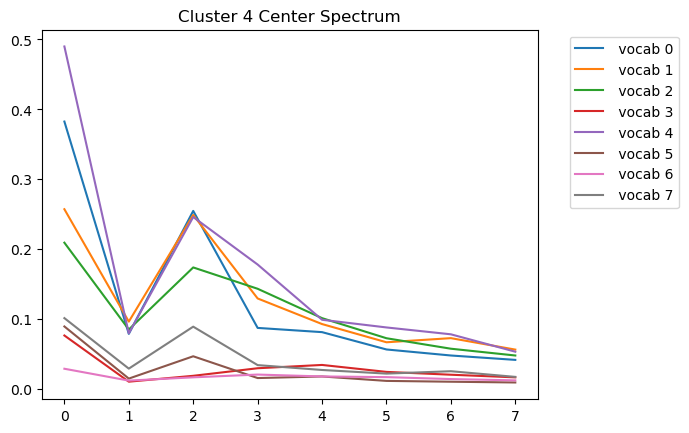

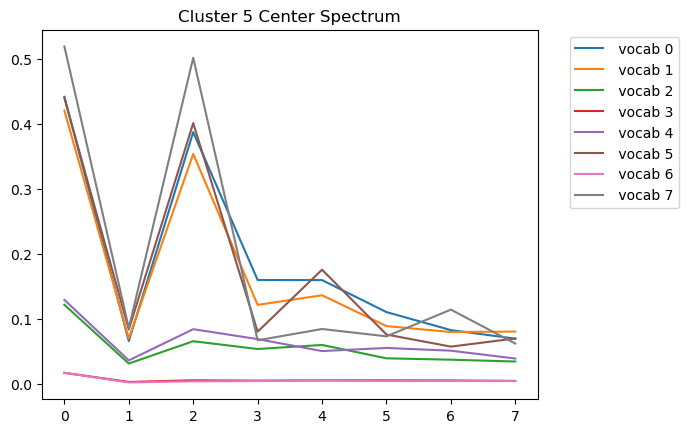

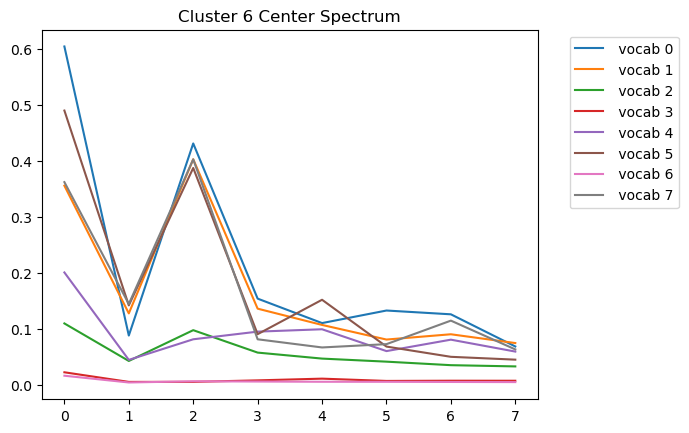

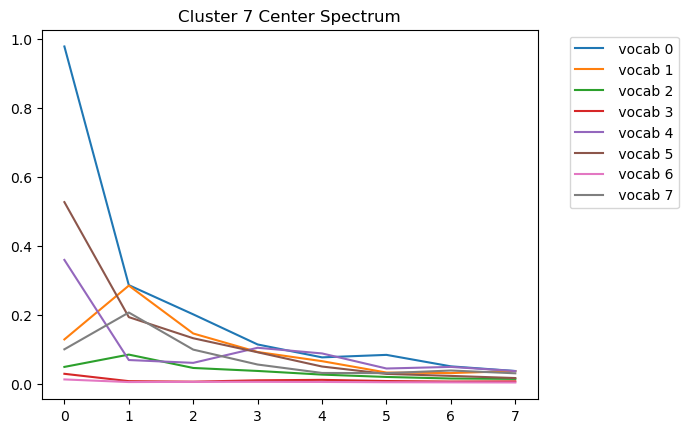

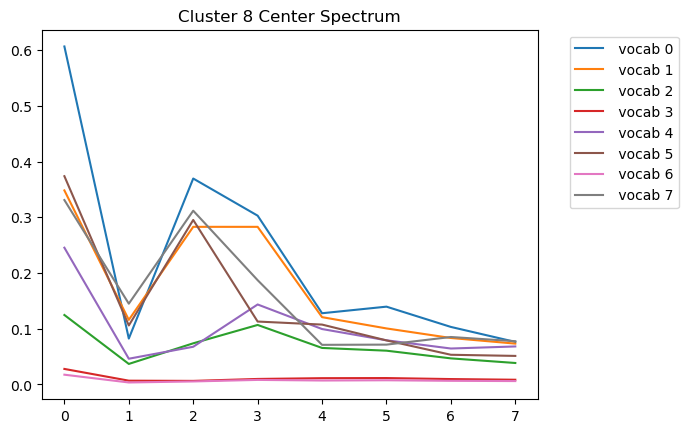

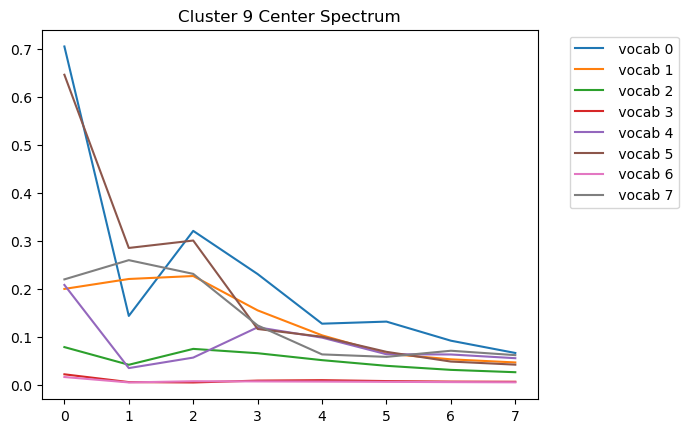

In [303]:
for (i, c) in enumerate(kmeans_spectrums.cluster_centers_):
    c_reshaped = c.reshape(bof_scaled.shape[1], bof_scaled.shape[2])
    for j in range(c_reshaped.shape[1]):
        plt.plot(c_reshaped[:, j], label=f' vocab {j}')
    plt.title(f'Cluster {i} Center Spectrum')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.show()

In [105]:
df_tsne = pd.DataFrame({
    'label_uid': filtered_ids,
    'tsne1': spectrum_pcs[:, 0], 
    'tsne2': spectrum_pcs[:, 1],
    'complexity': l_cross_values, 
})

print(df_tsne.head())
df_tsne.to_csv('Data/tsne_results_raw_value.csv', index=False)

        label_uid      tsne1      tsne2  complexity
0   day1p5_A01_96 -18.229231 -33.572823    1.956240
1  day1p5_A01_140  -6.559122 -32.572979    1.960171
2  day1p5_A01_154 -23.033148 -25.809118    1.963289
3   day1p5_A01_41 -29.130922 -25.921164    1.964749
4   day1p5_A01_68 -17.985437 -46.310333    1.959688


In [623]:
df_tsne[df_tsne['label_uid'] == 'day1p5_A03_10']

,label_uid,tsne1,tsne2,complexity
198,day1p5_A03_10,-6.416986,5.725533,0.969764


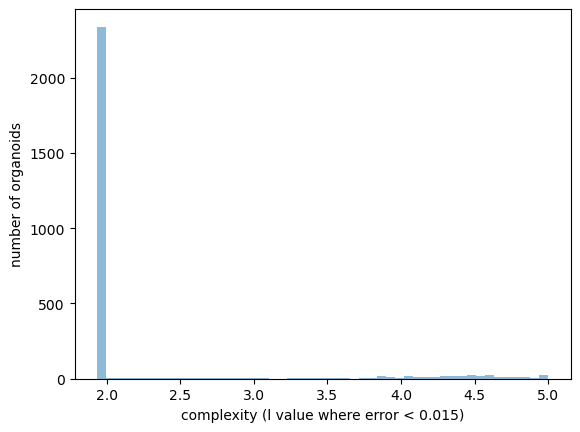

In [698]:
plt.hist(l_cross_values, bins=50, alpha=0.5)
plt.xlabel('complexity (l value where error < 0.015)')
plt.ylabel('number of organoids')
plt.show() 